# Traitement et Analyse de données de vente

In [1]:
# import des packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

### Découverte et structuration des données

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ventes = pd.read_excel('/content/drive/MyDrive/TP_Corporate_data_analytics/ventes.xlsx')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfa in position 16: invalid start byte

In [89]:
ventes.sample(5)

,date,produit,prix_unitaire,quantité,vendeur,région
963,2024-02-12,Télephone,220000.0,4.0,Alice,Nord
1272,2024-01-31,Casque,20000.0,4.0,Bob,Sud
580,2024-01-17,Cahrgeur,10000.0,2.0,Alice,Nord
391,2024-02-26,Souris,7000.0,3.0,Dora,Nord
647,2024-02-08,Casque,25000.0,NaN,Charlie,Ouest


In [90]:
ventes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1313 non-null   datetime64[ns]
 1   produit        1313 non-null   object        
 2   prix_unitaire  1287 non-null   float64       
 3   quantité       1286 non-null   float64       
 4   vendeur        1313 non-null   object        
 5   région         1313 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 61.7+ KB


#### Observations:


*   Notre ensemble de données comprend 1313 lignes et 6 colonnes
*   Les colonnes "quantité" et "prix_unitaire" sont de type numérique (float)
*   Les colonnes "région", "vendeur" et "produit" sont de type chaine de caractère
*   La colonne "date" est de type "datetime"

### Recherche d'incohérences, d'erreurs ou problèmes avec les données

In [91]:
# cherchons les occurrences de chaque variables catégorielles
print("................Occurrence des produits...........................\n")
print(ventes['produit'].value_counts())
print("\n................Occurrence des vendeurs...........................\n")
print(ventes['vendeur'].value_counts())
print("\n................Occurrence des régions...........................\n")
print(ventes['région'].value_counts())

................Occurrence des produits...........................

produit
Télephone     197
Cahrgeur      194
Tablette      193
Casque        190
Oridnateur    184
Souris        182
Clavier       173
Name: count, dtype: int64

................Occurrence des vendeurs...........................

vendeur
Fatou      214
Charlie    204
Alice      190
Gaston     185
Bob        184
Dora       171
Eddy       165
Name: count, dtype: int64

................Occurrence des régions...........................

région
Ouest    389
Nord     361
Sud      349
Est      214
Name: count, dtype: int64


#### Observation : Fautes d'orthographe dans la colonne "produit"

*   le nom Télephone pour Téléphone
*   le nom Cahrgeur pour Chargeur
*   le nom Oridnateur pour Ordinateur

<Axes: >

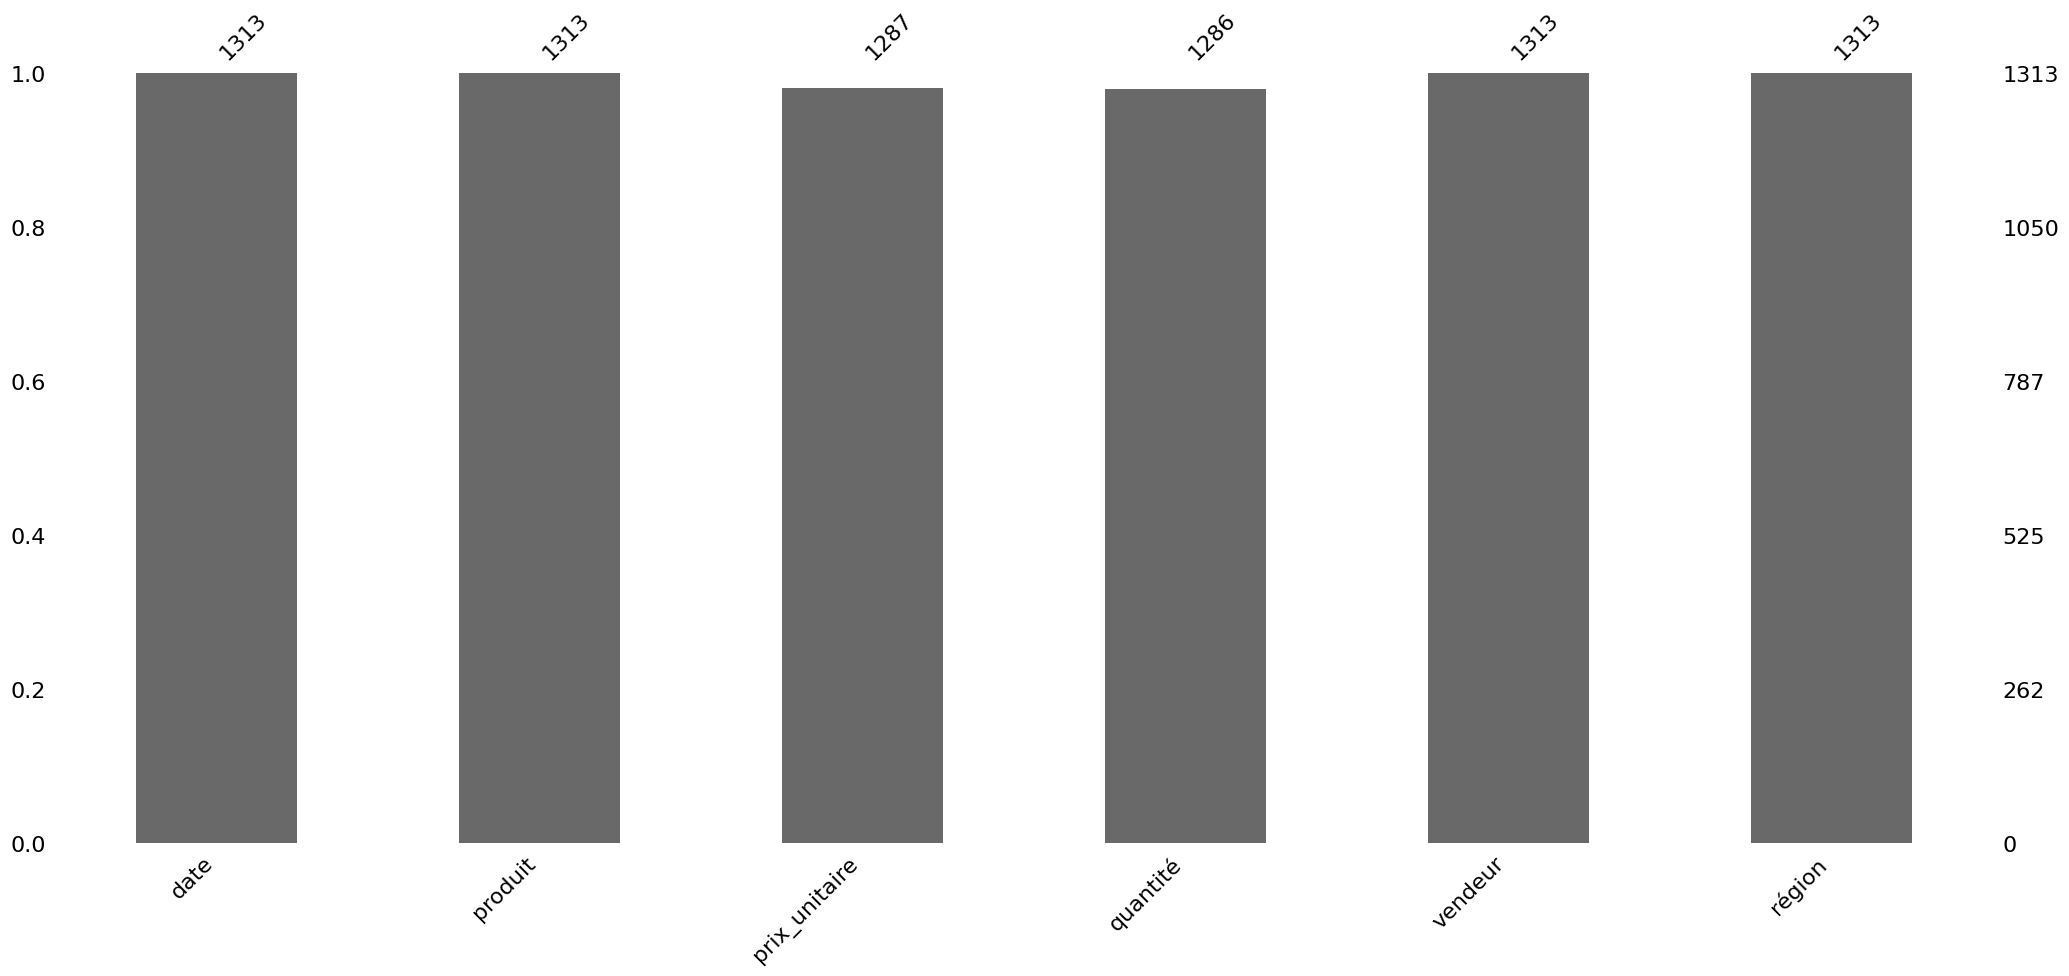

In [92]:
# Visualisation des valeurs manquantes
msno.bar(ventes)

#### Observations :


*   Pour les 1313 lignes de données, seuls les colonnes "prix_unitaire" et "quantité" présentes des valeurs manquantes
*   Pour la colonne "prix_unitaire", on a 1287 valeurs non null, soit 26 valeurs manquantes
*   Pour la colonne "quantité", on a 1286 valeurs non null, soit 27 valeurs manquantes



<Axes: >

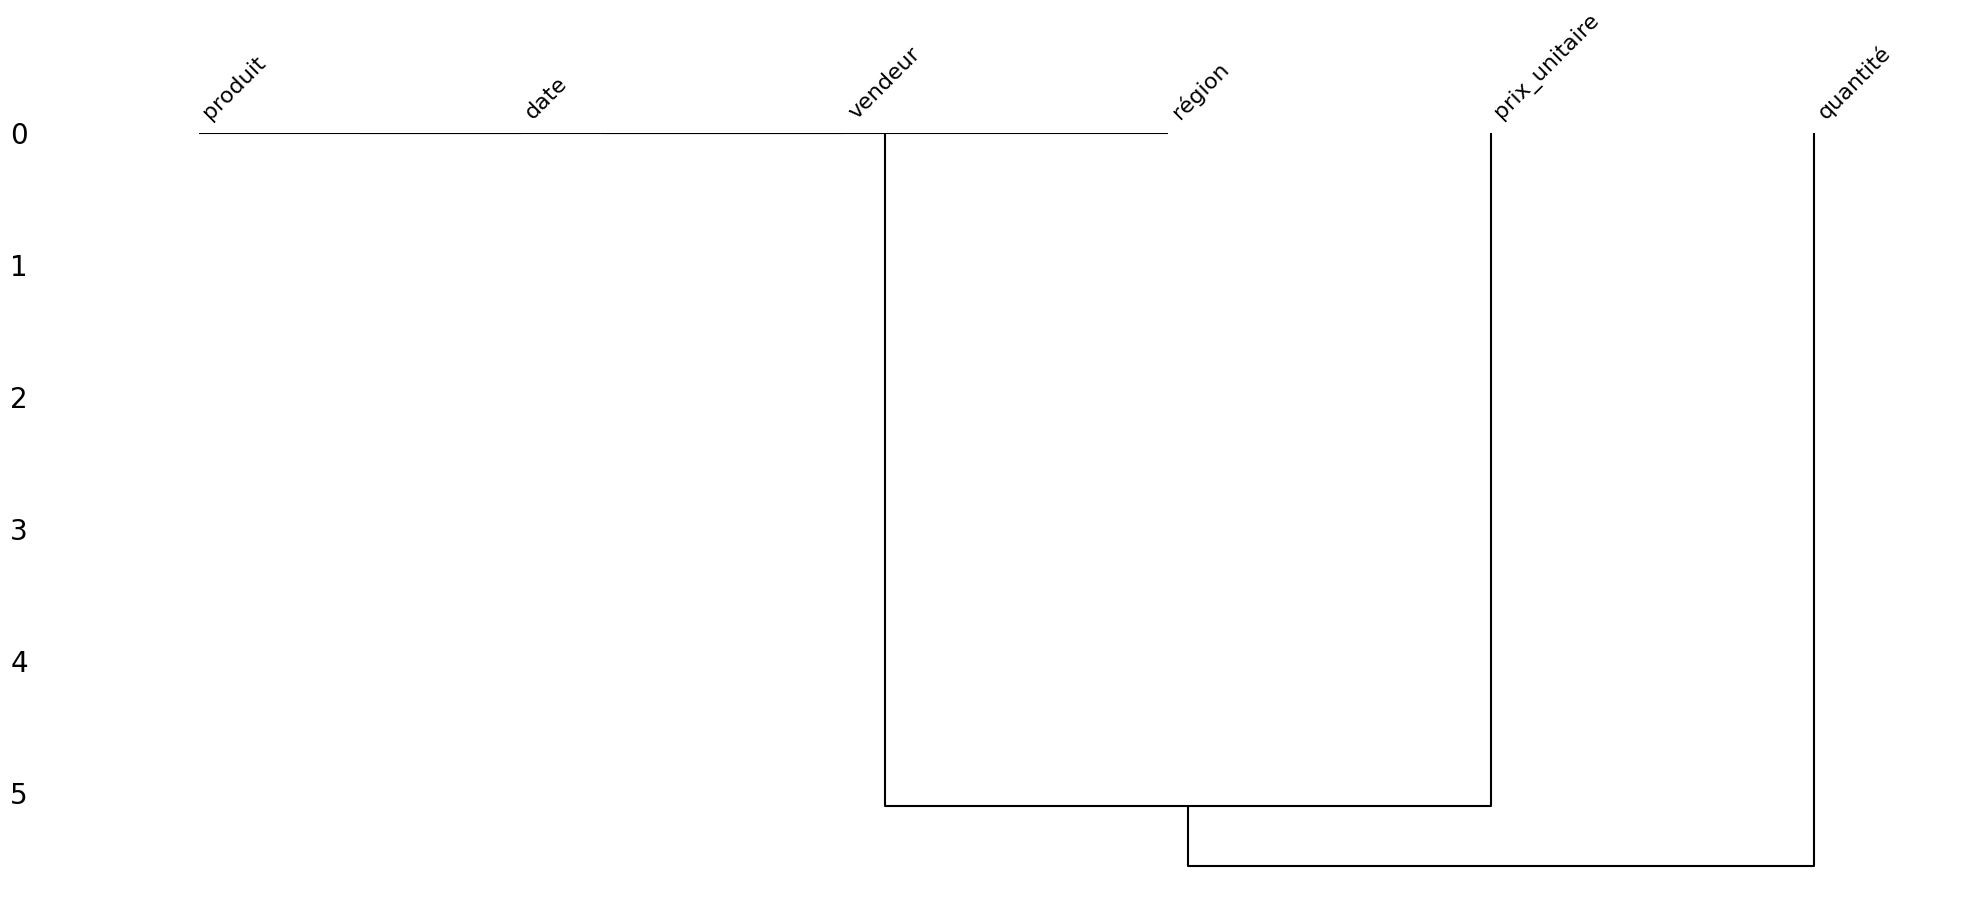

In [93]:
# Visualistion de la relation entre les colonnes avec les valeurs manquantes
msno.dendrogram(ventes)

#### Observations : On observe que


*   il existe un lien entre les valeurs manquantes de la colonne "prix_unitaire" et les valeurs des colonnes "produit", "date", "vendeur", "région". Cela pourrait indiquer que les données sont manquantes pour certains produits, dates, vendeurs ou régions spécifiques
*   il existe un lien entre les valeurs manquantes de la colonne "quantité" et les valeurs des autres colonnes
*   et puisque les colonnes "produit", "date", "vendeur", "région" n'ont pas de valeurs manquantes, on conclut que la relation se situe entre les colonnes "quantité" et "prix_unitaire"
*   On en déduit que si une entrée pour le prix unitaire est manquante, il est très probable que la quantité correspondante soit également manquante, et vice-versa.

### **Résumé des observations et approches pour le traitement des données:**


1.  La colonne "quantité" est de type float, or logiquement pour les types de produits vendus, les quantités devraient être des nombres entiers. Ici, nous ferons la conversion de **float** à **entier**.
2.  Les colonnes "région" et "produit" sont de type object, alors qu'elles représentes des catégories de région ou de produit. Ici, nous ferons la conversion de **object** à **category**
3.  La colonne "date" est de type datetime. Pour valoriser cette colonne dans notre analyse, nous allons la décomposer en " Jour"; "Mois"; "Année" et "Heure". Celà nous permettra d'analyser nos données selon les ventes, selon les jours, le mois, l'année ou encore l'heure
4.  En ce qui concerne les fautes de frappe dans la colonne "produit" issue de la numérisation des données:

*   "Cahrgeur" au lieu de "Chargeur"
*   "Oridnateur" au lieu de "Ordinateur"
*   "Télephone" au lieu de "Téléphone"
Il sera procédé à un remplaçement par les vrais nom de produit.

5.  Pour les valeurs manquantes dans la colonne "prix_unitaire", au vu du lien entre le prix_unitaire et la date, le vendeur, le produit" et la région de vente, il sera procéder à une imputation du prix unitaire manquant d'un produit par le prix unitaire le plus fréquent de ce produit fixé par le même vendeur, à la même date, même région.

6.  Pour les valeurs manquantes de la colonne "quantité", nous allons procéder à une imputation par l'algorithme de KNN, pour être sûre de s'appuyer sur toutes les autres caractéristiques.

### **Traitement des données**

1. Correction des valeurs de la colonne "produit"

In [94]:
# correction de la colonne produit
ventes['produit'] = ventes['produit'].replace('Cahrgeur', 'Chargeur')
ventes['produit'] = ventes['produit'].replace('Oridnateur', 'Ordinateur')
ventes['produit'] = ventes['produit'].replace('Télephone', 'Téléphone')

In [95]:
# vérifions
print(ventes['produit'].value_counts())

produit
Téléphone     197
Chargeur      194
Tablette      193
Casque        190
Ordinateur    184
Souris        182
Clavier       173
Name: count, dtype: int64


2. Modification des types de données des colonnes "région", "produit" et "vendeur"

In [96]:
# conversion des colonnes "région", "produit" du type object en category
ventes['région'] = ventes['région'].astype('category')
ventes['produit'] = ventes['produit'].astype('category')
# conversion de la colonne "vendeur" du type object en string
ventes['vendeur'] = ventes['vendeur'].astype('string')

In [97]:
ventes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1313 non-null   datetime64[ns]
 1   produit        1313 non-null   category      
 2   prix_unitaire  1287 non-null   float64       
 3   quantité       1286 non-null   float64       
 4   vendeur        1313 non-null   string        
 5   région         1313 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(2), string(1)
memory usage: 44.3 KB


3. Décomposition de la colonne "date" en colonnes "Jour", "Mois", "Année" et "Heure"

In [98]:
# Décomposons la colonne "date" en colonnes "Jour", "Mois", "Année" et "Heure"
ventes['Jour'] = ventes['date'].dt.day_name()
ventes['Mois'] = ventes['date'].dt.month_name()
ventes['Année'] = ventes['date'].dt.year
ventes['Heure'] = ventes['date'].dt.hour

In [99]:
# suppression de la colonne date
ventes.drop('date', axis=1, inplace=True)

In [100]:
ventes.sample(5)

,produit,prix_unitaire,quantité,vendeur,région,Jour,Mois,Année,Heure
249,Chargeur,8000.0,4.0,Fatou,Est,Wednesday,January,2024,0
920,Casque,25000.0,4.0,Fatou,Est,Wednesday,January,2024,0
925,Chargeur,NaN,3.0,Gaston,Ouest,Tuesday,February,2024,0
271,Clavier,18000.0,4.0,Charlie,Ouest,Thursday,January,2024,0
695,Tablette,180000.0,4.0,Bob,Sud,Tuesday,January,2024,0


4. Traitement des valeurs manquantes de la colonne "prix_unitaire"

Imputation du prix unitaire manquant d'un produit par le prix unitaire le plus
fréquent de ce produit fixé par le même vendeur, la même heure, le même jour, la même année, le même mois, et dans la même région

In [101]:
# regroupons les prix unitaire par groupes
# chaque groupe étant un ensemble de ligne du dataset ayant même valeur
# pour les colonnes "produit", "région", "vendeur", "jour", "mois", "année", "Heure"
prix_unitaire_par_group = ventes.groupby(['produit', 'région', 'vendeur', 'Jour', 'Mois', 'Année', 'Heure'])['prix_unitaire']
# Calcul du prix unitaire le plus fréquent pour chaque groupe
mode_prix_unitaire_par_group = prix_unitaire_par_group.transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
# Imputation des valeurs manquantes dans 'prix_unitaire' avec les modes calculés
ventes['prix_unitaire'] = ventes['prix_unitaire'].fillna(mode_prix_unitaire_par_group)


/tmp/ipykernel_20898/2162955555.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prix_unitaire_par_group = ventes.groupby(['produit', 'région', 'vendeur', 'Jour', 'Mois', 'Année', 'Heure'])['prix_unitaire']


In [102]:
print("Affichage des 5 premiers groupes formés et de leurs 'prix_unitaire' correspondants:")

for i, (group_key, group_data) in enumerate(prix_unitaire_par_group):
    if i >= 5: # Limit to first 5 groups for display
        break
    print(f"\nGroupe {i+1} - Clé: {group_key}")
    display(group_data.head())


Affichage des 5 premiers groupes formés et de leurs 'prix_unitaire' correspondants:

Groupe 1 - Clé: ('Casque', 'Est', 'Fatou', 'Friday', 'February', np.int32(2024), np.int32(0))


,prix_unitaire
542,25000.0



Groupe 2 - Clé: ('Casque', 'Est', 'Fatou', 'Friday', 'January', np.int32(2024), np.int32(0))


,prix_unitaire
25,25000.0
426,20000.0
1210,30000.0



Groupe 3 - Clé: ('Casque', 'Est', 'Fatou', 'Monday', 'February', np.int32(2024), np.int32(0))


,prix_unitaire
309,20000.0
1117,30000.0



Groupe 4 - Clé: ('Casque', 'Est', 'Fatou', 'Saturday', 'February', np.int32(2024), np.int32(0))


,prix_unitaire
560,25000.0
653,20000.0
773,25000.0
1259,25000.0



Groupe 5 - Clé: ('Casque', 'Est', 'Fatou', 'Saturday', 'January', np.int32(2024), np.int32(0))


,prix_unitaire
135,25000.0


In [103]:
# Vérifions s'il reste encore des valeurs manquantes dans la colonne 'prix_unitaire'
print(f"Nombre de valeurs manquantes dans 'prix_unitaire' après imputation : {ventes['prix_unitaire'].isnull().sum()}")

Nombre de valeurs manquantes dans 'prix_unitaire' après imputation : 8


#### Observation:
Après cette imputation, il reste encore des valeurs manquantes pour la colonne "prix_unitaire".
Nous allons donc procéder à deuxième imputation mais cette fois en utilisant le mode du prix_unitaire regroupé cette fois ci par produit, vendeur, région, mois, année. Nous allons exclure le jour et l'heure de vente du groupe, Parce que d'un point de vue métier, même si ce n'est pas le même jour ni la même heure, le prix d'un produit vendu par le même vendeur, serait semblable dans la même région; le même mois et la même année

In [104]:
# regroupons les prix unitaire par groupes
# chaque groupe étant un ensemble de ligne du dataset ayant même valeur
# pour les colonnes "produit", "région", "vendeur", "mois", "année"
prix_unitaire_par_group = ventes.groupby(['produit', 'région', 'vendeur', 'Mois', 'Année'])['prix_unitaire']
# Calcul du prix unitaire le plus fréquent pour chaque groupe
mode_prix_unitaire_par_group = prix_unitaire_par_group.transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Imputation des valeurs manquantes dans 'prix_unitaire' avec les modes calculés
ventes['prix_unitaire'] = ventes['prix_unitaire'].fillna(mode_prix_unitaire_par_group)


/tmp/ipykernel_20898/2859897087.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prix_unitaire_par_group = ventes.groupby(['produit', 'région', 'vendeur', 'Mois', 'Année'])['prix_unitaire']


In [105]:
# Vérifions s'il reste encore des valeurs manquantes dans la colonne 'prix_unitaire'
print(f"Nombre de valeurs manquantes dans 'prix_unitaire' après imputation : {ventes['prix_unitaire'].isnull().sum()}")

Nombre de valeurs manquantes dans 'prix_unitaire' après imputation : 0


### 5. Traitement des valeurs manquantes de la colonne "quantité"
Imputation des valeurs manquant de la colonne "quantité" par l'algorithme de KNN

###### identification et sélection des colonnes importantes pour l'algorithme

In [106]:
# Vérifions si les colonnes "Année" et "Heure" sont importantes pour l'algorithme
print("................Occurrence des années...........................\n")
print(ventes['Année'].value_counts())
print("\n................Occurrence des heures...........................\n")
print(ventes['Heure'].value_counts())

................Occurrence des années...........................

Année
2024    1313
Name: count, dtype: int64

................Occurrence des heures...........................

Heure
0    1313
Name: count, dtype: int64


##### Observations:
Les variables "Année" et "Heure" ne seront pas inclut dans l'algorithme de KNN, en raison du fait qu'elles ne contiennent que la même valeur pour toute les lignes, elles n'apporterons donc rien à l'algorithme

In [107]:
# sélection des colonnes catégorielles et numérique
colonnes_categorielles = ['produit', 'vendeur', 'région', 'Jour', 'Mois']
colonne_numerique = 'prix_unitaire'

In [108]:
# encodage onehotencoding des colonnes catégorielles
# Création d'une copie du DataFrame pour l'encodage et l'imputation afin de ne pas modifier l'original directement
ventes_encode = ventes.copy()

# Application de l'encodage one-hot sur les colonnes catégorielles
ventes_encode = pd.get_dummies(ventes_encode, columns=colonnes_categorielles, drop_first=False)

In [109]:
ventes_encode.head()

,prix_unitaire,quantité,Année,Heure,produit_Casque,produit_Chargeur,produit_Clavier,produit_Ordinateur,produit_Souris,produit_Tablette,...,région_Sud,Jour_Friday,Jour_Monday,Jour_Saturday,Jour_Sunday,Jour_Thursday,Jour_Tuesday,Jour_Wednesday,Mois_February,Mois_January
0,150000.0,4.0,2024,0,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
1,350000.0,3.0,2024,0,False,False,False,True,False,False,...,True,False,False,True,False,False,False,False,True,False
2,12000.0,4.0,2024,0,False,True,False,False,False,False,...,True,True,False,False,False,False,False,False,False,True
3,9000.0,3.0,2024,0,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
4,10000.0,2.0,2024,0,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [110]:
# Initialisation de l'imputer KNN avec 5 voisins
knn_imputer = KNNImputer(n_neighbors=5)

# Application de l'imputation sur l'ensemble du DataFrame encodé
# Note: KNNImputer retourne un tableau numpy, pas un DataFrame
imputed_data_array = knn_imputer.fit_transform(ventes_encode)

In [111]:
# Reconstruction du DataFrame avec les données imputées
df_imputed_knn = pd.DataFrame(imputed_data_array, columns=ventes_encode.columns)

# Mise à jour de la colonne 'quantité' dans le DataFrame original 'ventes'
ventes['quantité'] = df_imputed_knn['quantité']

#### Convertions finales des types de colonnes

In [112]:
# Conversion de la colonne 'quantité' en type entier
# On utilise 'round()' pour s'assurer que les valeurs sont des entiers avant la conversion
ventes['quantité'] = ventes['quantité'].round().astype(int)

In [113]:
# conersion des colonnes "Mois", "Jour", "Année" en type catégory
ventes['Mois'] = ventes['Mois'].astype('category')
ventes['Jour'] = ventes['Jour'].astype('category')
ventes['Année'] = ventes['Année'].astype('category')

In [114]:
ventes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   produit        1313 non-null   category
 1   prix_unitaire  1313 non-null   float64 
 2   quantité       1313 non-null   int64   
 3   vendeur        1313 non-null   string  
 4   région         1313 non-null   category
 5   Jour           1313 non-null   category
 6   Mois           1313 non-null   category
 7   Année          1313 non-null   category
 8   Heure          1313 non-null   int32   
dtypes: category(5), float64(1), int32(1), int64(1), string(1)
memory usage: 43.6 KB


#### **Création d'une nouvelle colonne "prix_total", à partir de "prix_unitaire" et "quantité"**
Cette colonne va nous permettre de calculer plus tard le chiffre d'affaire, par jour ou par mois pour chaque produit et d'apprécier peut être les vendeurs les plus dynamiques, les régions de bonne vente et autres choses.

In [115]:
# Création d'une nouvelle colonne "prix_total", à partir de "prix_unitaire" et "quantité"
ventes['prix_total'] = ventes['prix_unitaire'] * ventes['quantité']

#### Fin du traitement:
Nous allons récupérer l'ensemble de données finale issue du traitement dans un fichier excel

In [116]:
# sauvegardons l'ensemble de données dans un fichier excel
chemin_du_fichier = '/content/ventes_traites.xlsx'
ventes.to_excel(chemin_du_fichier, index=False)

# Analyse de l'ensemble de données traiter

#### Formulons quelques hypothèses d'analyses

1.   La quantité de produit vendu dépend du prix unitaire
2.   Le chiffre d'affaires total varie-t-il significativement d'un produit à l'autre ?
3.   Certains vendeurs génèrent-ils un chiffre d'affaires total plus élevé que d'autres ?
4.   Le chiffre d'affaires total présente-t-il des variations saisonnières ou hebdomadaires (par mois ou par jour de la semaine) ?
5.   Existe-t-il une corrélation entre la région et le type de produit le plus vendu ?

In [117]:
# import de l'ensemble de données traité
ventes = pd.read_excel('/content/ventes_traites.xlsx')

### Analyse univarié de l'ensemble de données

In [118]:
# résumé des données
# Nous allons exclure l'année et l'heure des statistiques descriptives, parce que les valeurs de ces colonnes ne varient pas
ventes[['quantité', 'prix_unitaire', 'prix_total']].describe()

,quantité,prix_unitaire,prix_total
count,1313.000000,1313.000000,1.313000e+03
mean,3.006855,119224.676314,3.531401e+05
std,1.407985,136953.533603,4.741137e+05
min,1.000000,7000.000000,7.000000e+03
25%,2.000000,12000.000000,3.500000e+04
50%,3.000000,25000.000000,1.000000e+05
75%,4.000000,180000.000000,6.000000e+05
max,5.000000,450000.000000,2.250000e+06


### **Interprètation**
1. Aucun client n'a acheté un produit pour une quantité dépassant 5 unités; 25% des clients achètent moins de 2 unités de produits; la moitié des clients achètent moins de 3 unités de produits et 75% des clients achètent moins de 4 unités de produits
2. Le prix unitaire moyen des produits est de 119224.676314

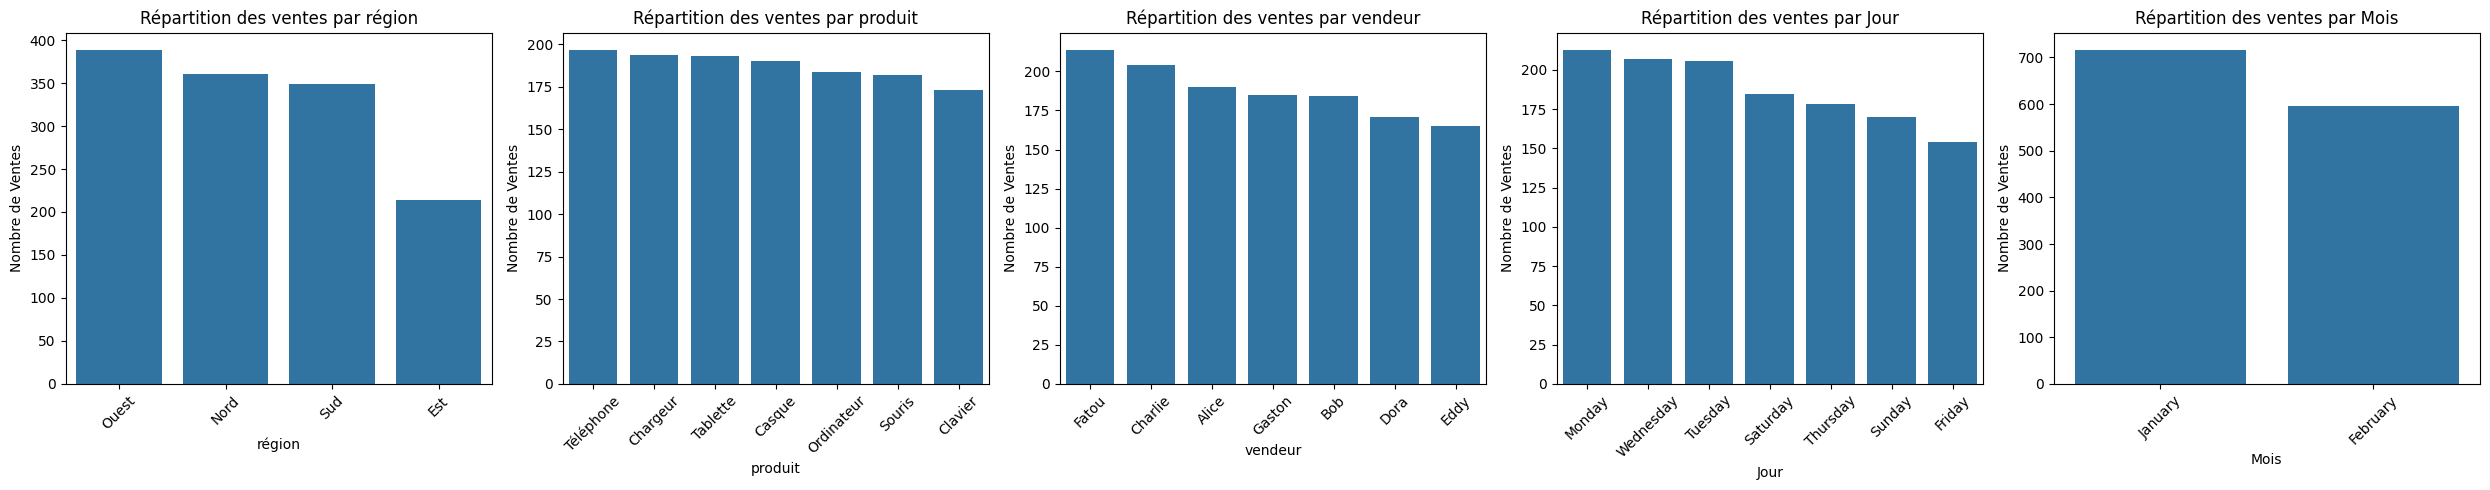

In [135]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 5))
axes = axes.flatten()

colonnes = ['région', 'produit', 'vendeur', 'Jour', 'Mois']

for i, col in enumerate(colonnes):
    sns.countplot(data=ventes, x=col, order=ventes[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Répartition des ventes par {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de Ventes')

plt.tight_layout()
plt.show()

### Interprètation


1.   Il y a eu plus d'affluence de vente dans le mois de Janvier qu'en Février dans l'ensemble des régions
2.   Vendredi est le jour de la semaine ou il y a moins de client et Lundi le jour de plus d'affluence. Mais en général l'affluence est quasiment la même tous les jours de la semaine et dans l'ensemble des régions.
3.   L'intérêt est porté sur tous les produits dans l'ensemble régions, mais le produit le plus vendu est le Téléphone
4.   La région ou il y a moins d'affluence de vente est la région de l'Est. Celle avec le plus de vente est la région de l'Ouest. L'écart d'affluence entre la région de l'Est avec les autres est vraiment grande
5.   Eddy est le vendeur qui reçoit le moins de client, et Fatou est celui qui en reçoit le plus.



### Analyse bivariée (deux à deux des variables) de l'ensemble de données

#### Visualisation de la répartition des ventes

In [120]:
# répartion des ventes par "région" en fonction du "vendeur"
# répartion des ventes par "région" en fonction du "Jour"
# répartion des ventes par "région" en fonction du "Mois"
# répartion des ventes par "région" en fonction du "produit"
# répartion des ventes par "Jour" en fonction du "vendeur"
# répartion des ventes par "Jour" en fonction du "produit"
# répartion des ventes par "Jour" en fonction du "Mois"
# répartion des ventes par "vendeur" en fonction du "produit"
# répartion des ventes par "vendeur" en fonction du "Jour"
# répartion des ventes par "Vendeur" en fonction du "Mois"
# répartion des ventes par "produit" en fonction du "Mois"
# répartion des ventes par "produit" en fonction du "vendeur"

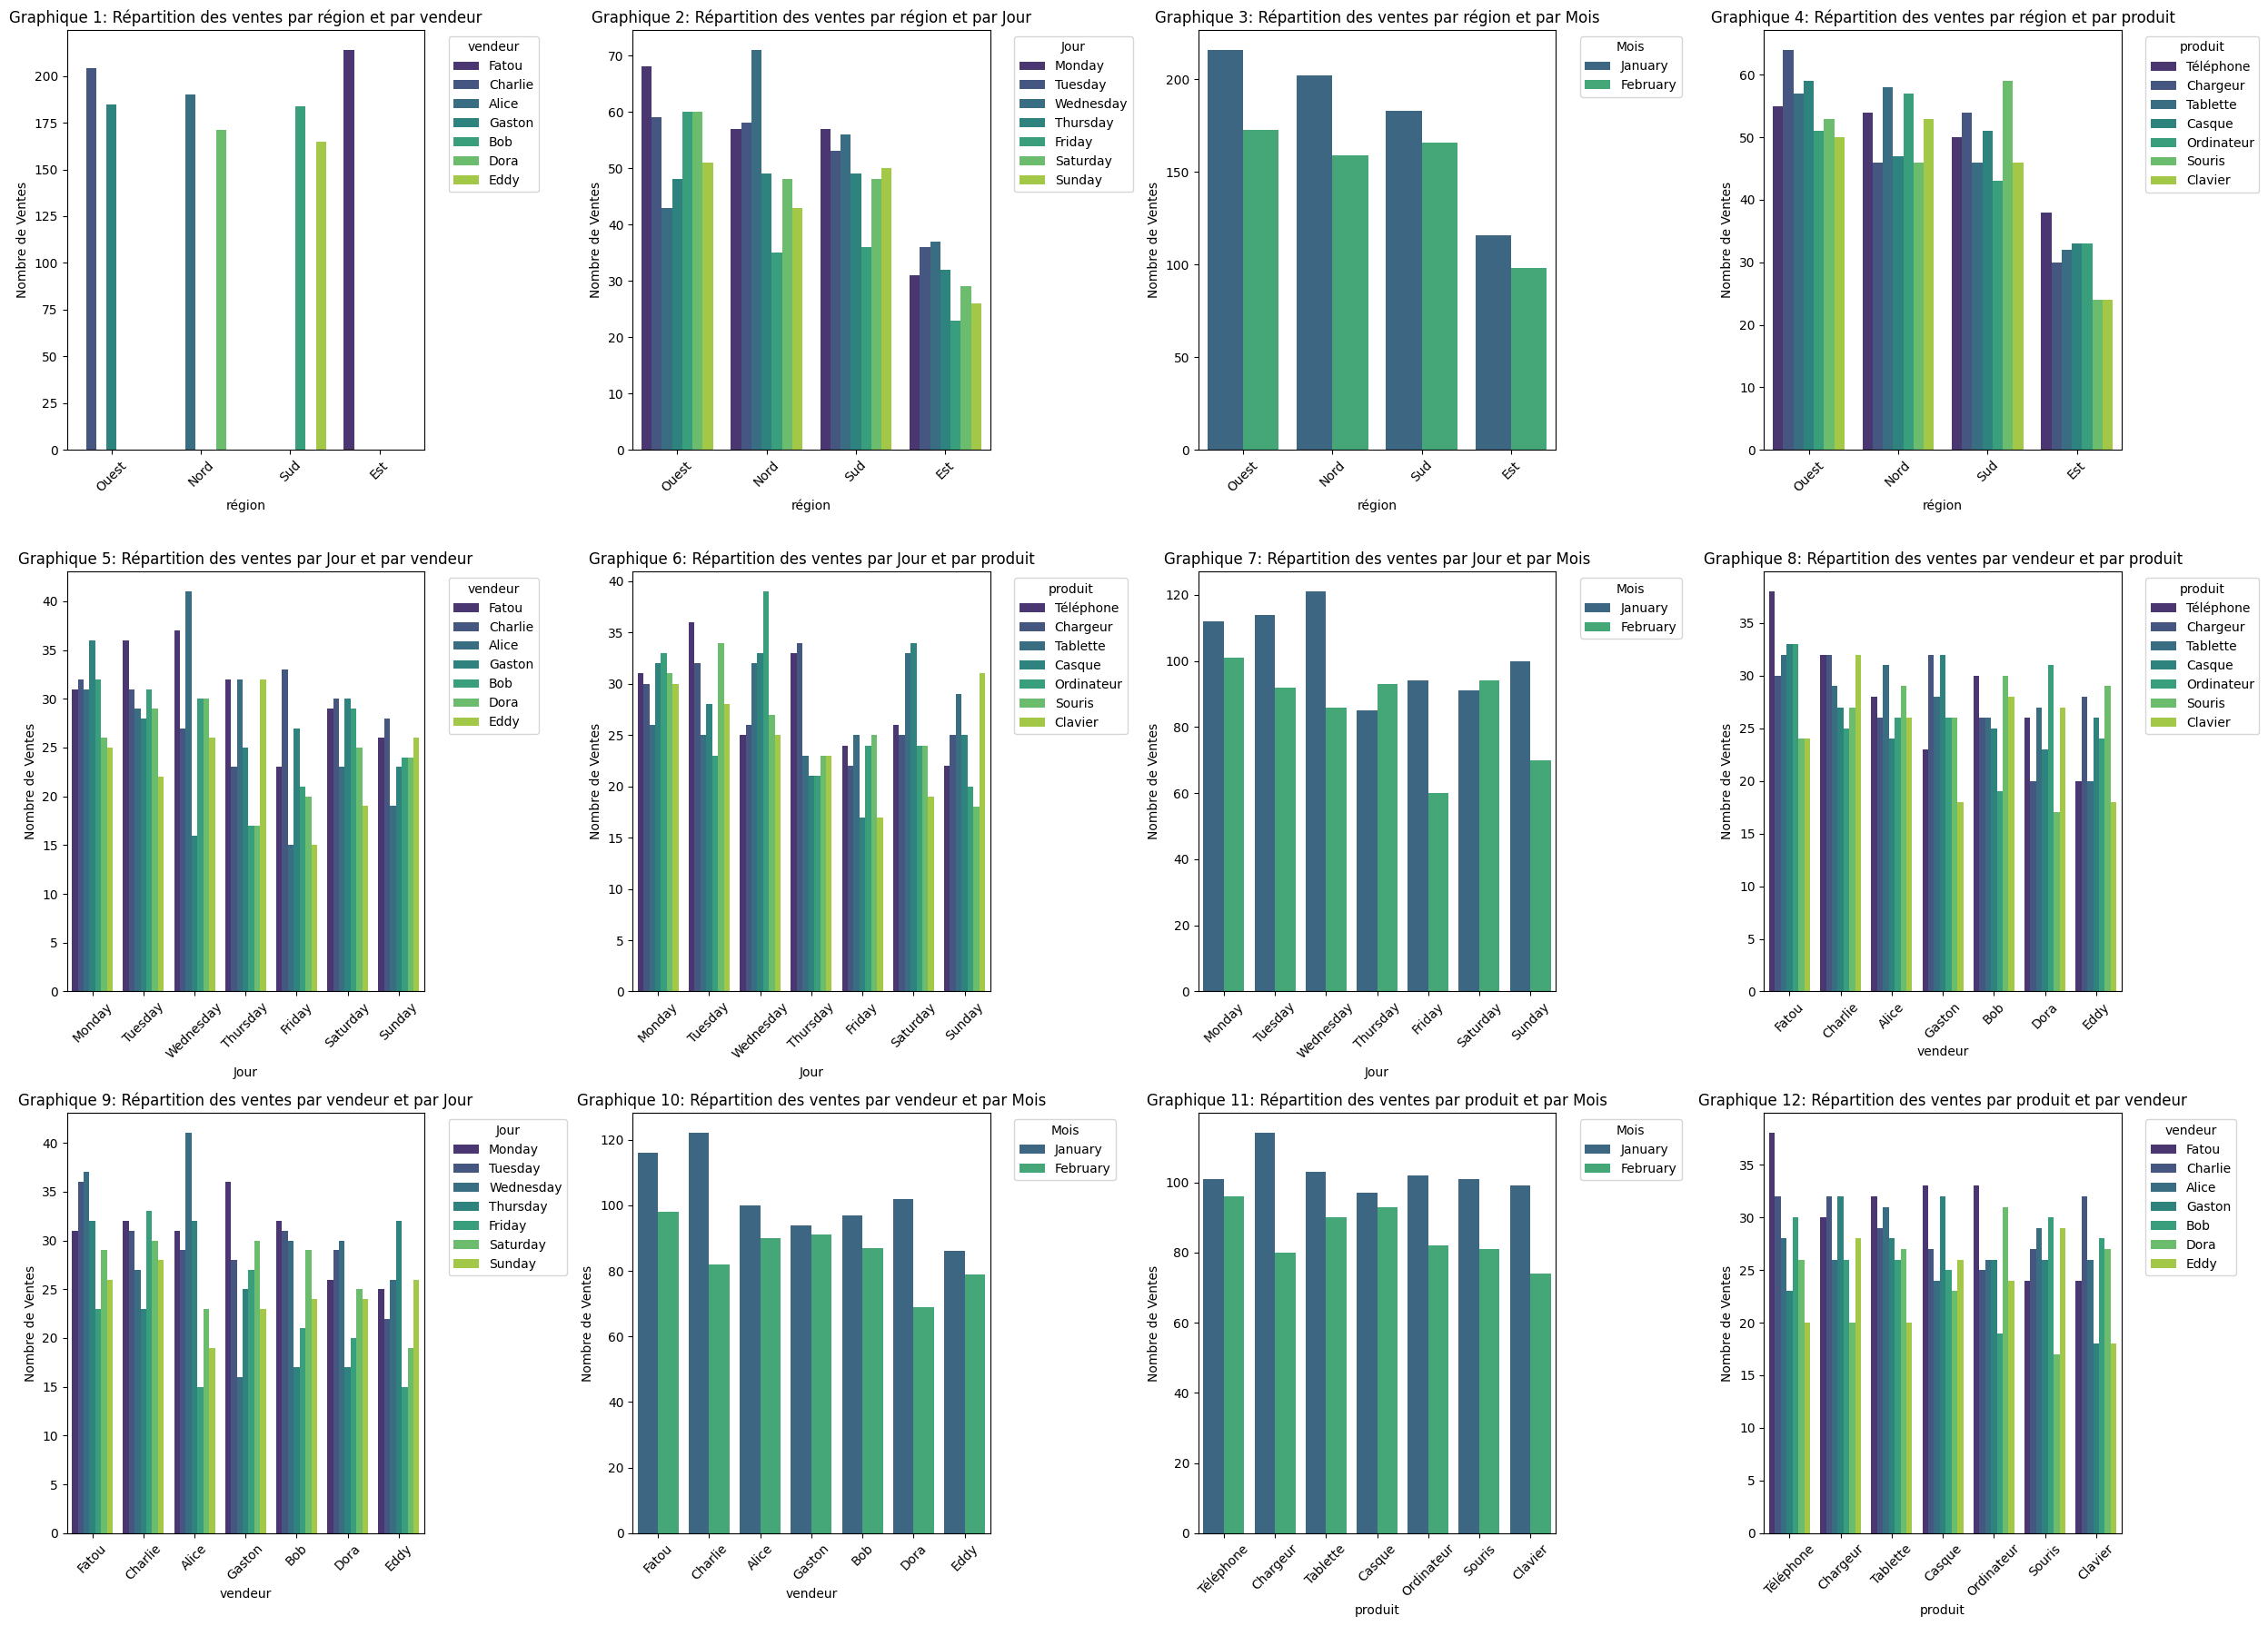

In [121]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 18))
axes = axes.flatten()

combinaisons = [
    ('région', 'vendeur'), ('région', 'Jour'), ('région', 'Mois'), ('région', 'produit'),
    ('Jour', 'vendeur'), ('Jour', 'produit'), ('Jour', 'Mois'),
    ('vendeur', 'produit'), ('vendeur', 'Jour'), ('vendeur', 'Mois'),
    ('produit', 'Mois'), ('produit', 'vendeur')
]

# ordre d'affichage des jours et mois sur les graphes
jour_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
mois_order = ["January", "February"]

for i, (col1, col2) in enumerate(combinaisons):
    ax = axes[i]

    # Determine the order for the columns if they are 'Jour' or 'Mois'
    if col1 == 'Jour':
        order1 = jour_order
    elif col1 == 'Mois':
        order1 = mois_order
    else:
        order1 = ventes[col1].value_counts().index

    if col2 == 'Jour':
        order2 = jour_order
    elif col2 == 'Mois':
        order2 = mois_order
    else:
        order2 = ventes[col2].value_counts().index

    sns.countplot(data=ventes, x=col1, hue=col2, ax=ax, palette='viridis', order=order1, hue_order=order2)
    ax.set_title(f'Graphique {i+1}: Répartition des ventes par {col1} et par {col2}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel(col1)
    ax.set_ylabel('Nombre de Ventes')
    ax.legend(title=col2, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

### Interprétation
1.   D'une région à une autre,


*   L'affluence des ventes s'est plus prononcé en Janvier qu'en Février, même si c'est relativement la même chose (voir graphique 3)
*   On observe plus de vente les Lundi dans les région de l'Ouest et du Sud, plus de vente les Mercredi dans les régions du Nord et de l'Est. Cela suggère qu'il y a une facilité à acheter ces jours précis dans ces régions peut être cela a une raison culturelle (voir graphique 2)


2.   Fatou a vendu plus de téléphone que quiconque, cela suppose qu'elle dispose de compétence spéciale dans la vente de ce produit ou que le besoin de la population de la région ou elle se situe (graphique 8)

3.   Le jour le plus abondant en terme de ventes d'Alice est le Mercredi, peut être son jour de chance (voir graphique 9)



### Analyse de la relation entre la quantité de produit vendu et du prix unitaire

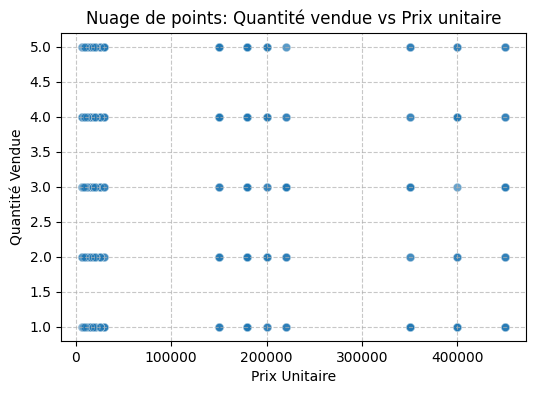

In [122]:
# Visualisons la relation entre le prix unitaire et la quantité vendue
plt.figure(figsize=(6, 4))
sns.scatterplot(data=ventes, x='prix_unitaire', y='quantité', alpha=0.2)
plt.title('Nuage de points: Quantité vendue vs Prix unitaire')
plt.xlabel('Prix Unitaire')
plt.ylabel('Quantité Vendue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Interprétation
Il n'existe pas un modèle d'évolution de la quantité de produit en fonction du prix de vente de l'unité du produit

In [123]:
# calcule de la corrélation entre prix unitaire et la quantité vendue
correlation = ventes['prix_unitaire'].corr(ventes['quantité'])
print(f"La corrélation de Pearson entre le prix unitaire et la quantité vendue est : {correlation:.2f}")

La corrélation de Pearson entre le prix unitaire et la quantité vendue est : -0.03


#### Interprétation
La corrélation est très faible, ce qui suggère une dépendance quasi-inexistante entre la quantité vendue et le prix unitaire dans ces données. L'hypothèse 1 selon laquelles, plus le prix unitaire augmente la quantité acheter diminue n'est pas vérifié. Il n'existe pas une telle relation entre le prix unitaire et la quantité achetée

#### Analyse de l'évolution du chiffre d'affaires total d'un produit à l'autre ?

In [124]:
# Calcul du chiffre d'affaires total par produit
chiffre_affaires_produit = ventes.groupby('produit')['prix_total'].sum().sort_values(ascending=False).reset_index()

/tmp/ipykernel_20898/3672536310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='produit', y='prix_total', data=chiffre_affaires_produit, palette='magma')


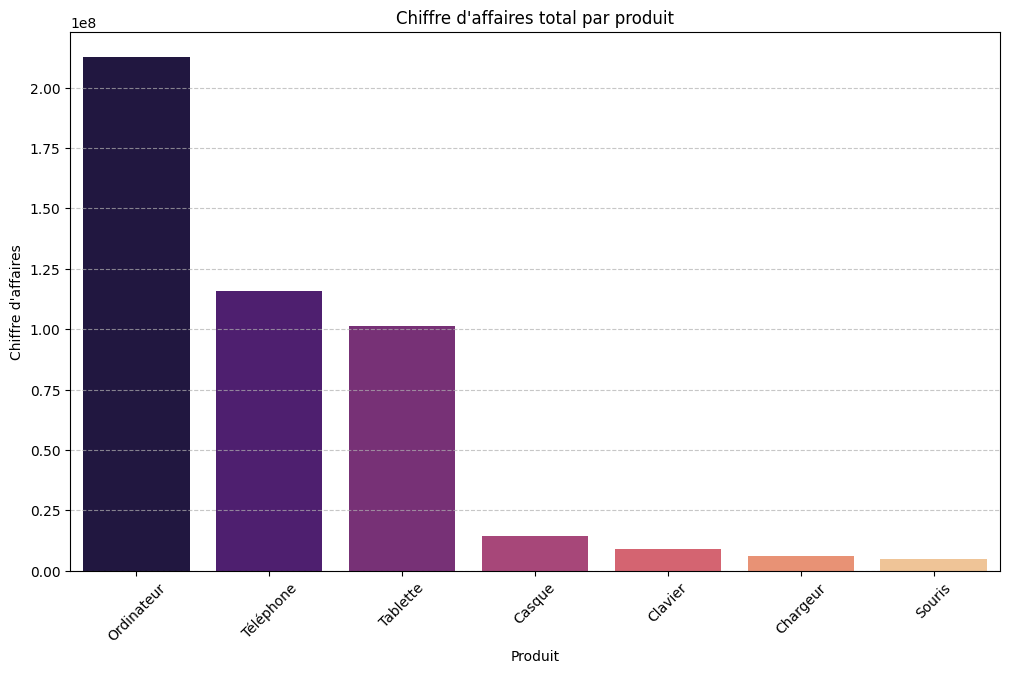

In [125]:
# Répartition du chiffre d'affaires par le type de produit
plt.figure(figsize=(12, 7))
sns.barplot(x='produit', y='prix_total', data=chiffre_affaires_produit, palette='magma')
plt.title('Chiffre d\'affaires total par produit')
plt.xlabel('Produit')
plt.ylabel('Chiffre d\'affaires')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interprétation
1.  Bien que le produit le plus vendu soit le Téléphone, l'Ordinateur fait le plus grand chiffre d'affaire et la Souris le chiffre d'affaire le plus petit
2.  La répartition du chiffre d'affaire par produit indique que d'un produit à un autre le chiffre d'affaire, varie fortement. Cette répartition est fortement déséquilibrée.


In [126]:
# Réalisons un test d'ANOVA
produit_groups = []
for produit_type in ventes['produit'].unique():
    produit_groups.append(ventes[ventes['produit'] == produit_type]['prix_total'])

f_statistic, p_value = f_oneway(*produit_groups)

print(f"Statistique F: {f_statistic:.2f}")
print(f"Valeur p: {p_value:.3f}")

alpha = 0.05

Statistique F: 492.00
Valeur p: 0.000


#### Interprétation:
Avec une valeur p_value de 0.000 inférieure à 0.05, nous rejetons l'hypothèse nulle.
Cela signifie qu'il existe une différence significative dans le chiffre d'affaires total entre les différents produits.

### Analyse de la relation entre chiffre d'affaire et vendeurs ?

In [127]:
# Calcul du chiffre d'affaires total par vendeur
chiffre_affaires_vendeur = ventes.groupby('vendeur')['prix_total'].sum().sort_values(ascending=False).reset_index()

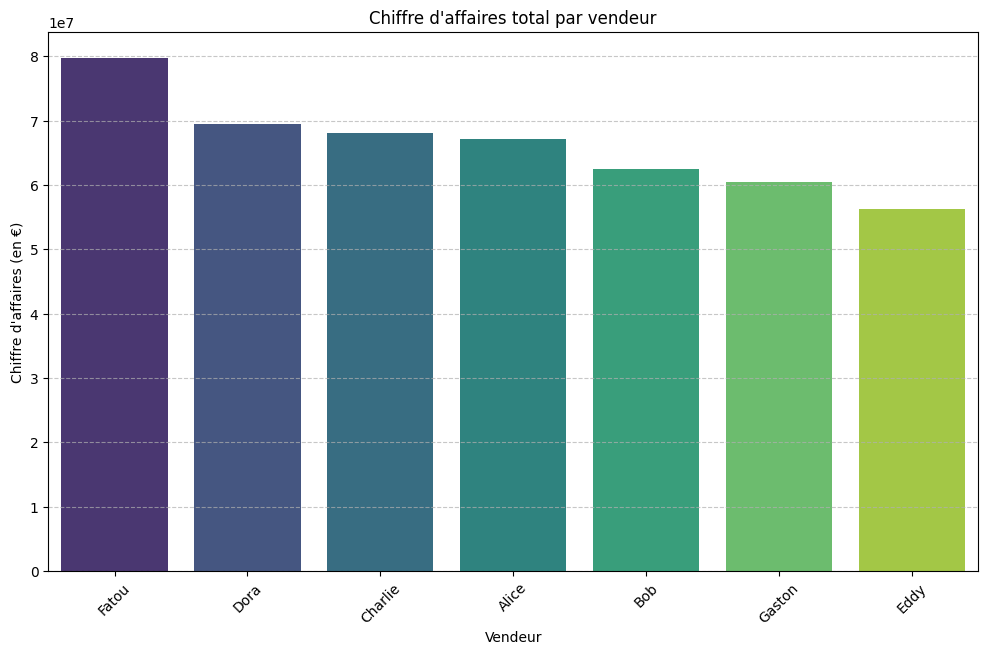

In [128]:
# Visualisation du chiffre d'affaires par vendeur
plt.figure(figsize=(12, 7))
sns.barplot(x='vendeur', y='prix_total', data=chiffre_affaires_vendeur, palette='viridis', hue='vendeur', legend=False)
plt.title('Chiffre d\'affaires total par vendeur')
plt.xlabel('Vendeur')
plt.ylabel('Chiffre d\'affaires (en €)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpétation
Le chiffre d'affaire varie tres peu d'un vendeur à l'autre. Mais la vendeuse Fatou est à encourager

In [129]:
# test ANOVA
vendeur_groups = []
for vendeur_type in ventes['vendeur'].unique():
    vendeur_groups.append(ventes[ventes['vendeur'] == vendeur_type]['prix_total'])

f_statistic, p_value = f_oneway(*vendeur_groups)

print(f"Statistique F: {f_statistic:.2f}")
print(f"Valeur p: {p_value:.3f}")
alpha = 0.05


Statistique F: 0.61
Valeur p: 0.720


#### Interprétation:
Avec une valeur p de 0.720 supérieure à 0.05, nous ne rejetons pas l'hypothèse nulle.
Cela signifie qu'il n'y a pas de différence statistiquement significative dans le chiffre d'affaires total entre les différents vendeurs. Le chiffre d'affaire ne dépend pas du venseur

#### Analyse de la varioation du chiffre d'affaires total par jour de la semaine ?

In [130]:
# ordre des jours de la semaine pour une meilleure visualisation
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calcul du chiffre d'affaires total par jour de la semaine
chiffre_affaires_jour = ventes.groupby('Jour')['prix_total'].sum().reindex(day_order).dropna().reset_index()

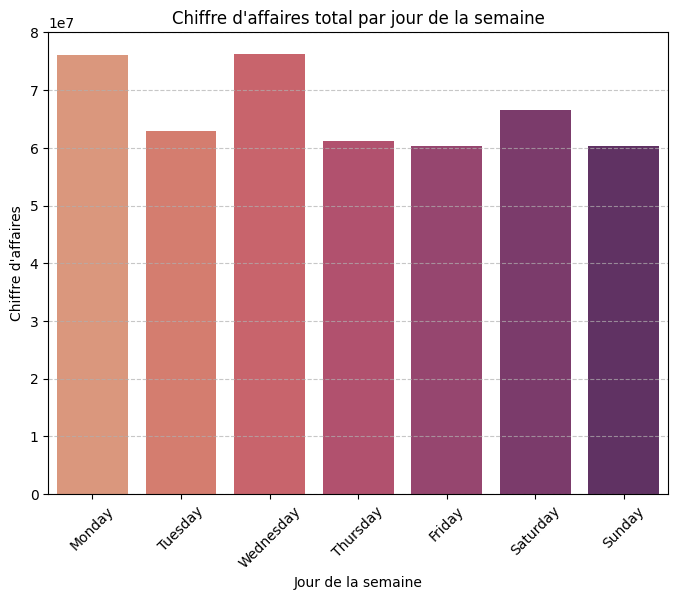

In [131]:
# Visualisation du chiffre d'affaires par jour
plt.figure(figsize=(8, 6))
sns.barplot(x='Jour', y='prix_total', data=chiffre_affaires_jour, palette='flare', hue='Jour', legend=False)
plt.title('Chiffre d\'affaires total par jour de la semaine')
plt.xlabel('Jour de la semaine')
plt.ylabel('Chiffre d\'affaires')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interprétation
On observe qu'il n'existe pas une différence significative de chiffre d'affaire entre les jours de la semaines

In [132]:
# Test Statistique (ANOVA) pour les jours de la semaine
jour_groups = []
for jour_type in ventes['Jour'].unique():
    jour_groups.append(ventes[ventes['Jour'] == jour_type]['prix_total'])

# Exécution du test ANOVA
f_statistic_jour, p_value_jour = f_oneway(*jour_groups)

print(f"Statistique F (Jour): {f_statistic_jour:.2f}")
print(f"Valeur p (Jour): {p_value_jour:.3f}")

alpha = 0.05

Statistique F (Jour): 0.57
Valeur p (Jour): 0.752


#### Interprétation:
Avec une valeur p de 0.752, supérieure à 0.05, nous ne rejetons pas l'hypothèse nulle.
Cela signifie qu'il n'y a pas de différence statistiquement significative dans le chiffre d'affaires total entre les différents jours de la semaine.

### Explorons la relation entre la région et le type de produit le plus vendu

In [133]:
# Calcul du nombre de ventes par produit et par région (tableau de contingence)
ventes_region_produit = pd.crosstab(ventes['région'], ventes['produit'])

In [134]:
# Test Statistique de Chi-carré
chi2, p_value, dof, expected = chi2_contingency(ventes_region_produit)

print(f"Statistique du Chi-carré: {chi2:.2f}")
print(f"Valeur p: {p_value:.3f}")
print(f"Degrés de liberté: {dof}")

alpha = 0.05

Statistique du Chi-carré: 12.23
Valeur p: 0.835
Degrés de liberté: 18


#### Interprétation:
Avec une valeur p de 0.835 (supérieure à 0.05), nous ne rejetons pas l'hypothèse nulle.
Cela signifie qu'il n'y a pas d'association statistiquement significative entre la région et le type de produit le plus vendu.

### **Conclusions sur chaque hypothèse d'analyse :**

1.  **Hypothèse 1: La quantité de produit vendu dépend du prix unitaire.**
    *   **Conclusion:** La corrélation entre le prix unitaire et la quantité vendue est très faible (-0.03), ce qui suggère une dépendance quasi-inexistante entre ces deux variables dans vos données.

2.  **Hypothèse 2: Le chiffre d'affaires total varie-t-il significativement d'un produit à l'autre ?**
    *   **Conclusion:** Oui, le test ANOVA (p-value = 0.000) a montré qu'il existe une différence statistiquement significative dans le chiffre d'affaires total entre les différents produits. Certains produits contribuent donc beaucoup plus au chiffre d'affaires que d'autres.

3.  **Hypothèse 3: Certains vendeurs génèrent-ils un chiffre d'affaires total plus élevé que d'autres ?**
    *   **Conclusion:** Non, le test ANOVA (p-value = 0.720) a indiqué qu'il n'y a pas de différence statistiquement significative dans le chiffre d'affaires total généré par les différents vendeurs.

4.  **Hypothèse 4: Le chiffre d'affaires total présente-t-il des variations hebdomadaires (par jour de la semaine) ?**
    *   **Conclusion:**Le test ANOVA n'a pas révélé de différences statistiquement significatives dans le chiffre d'affaires total entre les différents jours de la semaine (p-value = 0.752).

5.  **Hypothèse 5: Existe-t-il une corrélation entre la région et le type de produit le plus vendu ?**
    *   **Conclusion:** Non, le test du Chi-carré (p-value = 0.835) a montré qu'il n'y a pas d'association statistiquement significative entre la région et le type de produit le plus vendu.


### **Nos recommandations à l'endroit de l'entreprise**


1.   Revoir la communication ou le marketing dans la région de l'Est. Celà permettra aux potentiels clients de s'interresser plus aux produits de l'entreprise dans cette région, de gagner plus de client et de réduire l'écart d'affluence entre cette région et les autres régions qui est vraiment grande. On peut aussi tenter de changer les vendeurs de cette région
2.   Puisqu'il existe des différences significatives dans le chiffre d'affaires entre les produits, l'entreprise pourrait envisager de concentrer ses efforts marketing et de vente sur les produits les plus performants. Une analyse des bénéfices engendrés par chaque produit serait également utile.


Réalisé par :
- LAOUROU     Jesu kristi Dunjuoyinlo   14636821
- SENOU       Axel                      17433122